# Medical Data Analysis

## Objective

The goal of this notebook is to analyze the medical characteristics of the BraTS2020 dataset.

Unlike traditional exploratory data analysis (EDA), this notebook focuses on understanding tumor properties and MRI characteristics that directly influence preprocessing, data sampling, model architecture, and training strategy.

The findings obtained here will guide the design of the computer vision pipeline.

In [1]:
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd

import nibabel as nib

import matplotlib.pyplot as plt

from tqdm.notebook import tqdm

In [2]:
DATASET_PATH = Path(
    "/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"
)

patients = sorted(
    [p for p in DATASET_PATH.iterdir() if p.is_dir()]
)

In [3]:
def get_modality_path(patient_path, modality):

    for file in patient_path.glob("*.nii"):

        name = file.stem.lower()

        if modality == "seg":

            if "seg" in name:
                return file

        else:

            if f"_{modality}" in name:
                return file

    raise FileNotFoundError(
        f"{modality} not found for {patient_path.name}"
    )

# Tumor Region Distribution

Each segmentation mask contains different tumor subregions.

The objective of this analysis is to quantify the number of voxels belonging to each BraTS label across the entire dataset.

Understanding class distribution helps identify class imbalance and guides the selection of suitable loss functions during training.

In [4]:
label_voxel_counts = {

    0: 0,

    1: 0,

    2: 0,

    4: 0
}

In [5]:
for patient in tqdm(patients):

    seg_path = get_modality_path(patient, "seg")

    mask = nib.load(str(seg_path)).get_fdata()

    unique, counts = np.unique(mask, return_counts=True)

    for label, count in zip(unique.astype(int), counts):

        label_voxel_counts[label] += count

  0%|          | 0/369 [00:00<?, ?it/s]

In [6]:
label_voxel_counts

{0: np.int64(3257699276),
 1: np.int64(8161996),
 2: np.int64(21302318),
 4: np.int64(7268410)}

In [7]:
label_df = pd.DataFrame({

    "Label": label_voxel_counts.keys(),

    "Voxel Count": label_voxel_counts.values()

})

label_df

,Label,Voxel Count
0,0,3257699276
1,1,8161996
2,2,21302318
3,4,7268410


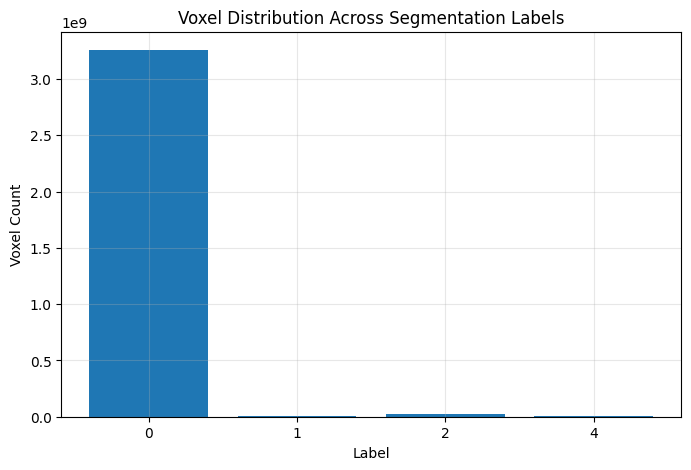

In [8]:
plt.figure(figsize=(8,5))

plt.bar(

    label_df["Label"].astype(str),

    label_df["Voxel Count"]

)

plt.title("Voxel Distribution Across Segmentation Labels")

plt.xlabel("Label")

plt.ylabel("Voxel Count")

plt.grid(alpha=.3)

plt.show()

In [9]:
label_df["Percentage"] = (

    label_df["Voxel Count"]

    /

    label_df["Voxel Count"].sum()

) * 100

label_df

,Label,Voxel Count,Percentage
0,0,3257699276,98.885006
1,1,8161996,0.247751
2,2,21302318,0.646616
3,4,7268410,0.220627


In [10]:
tumor_df = label_df[label_df["Label"] != 0].copy()

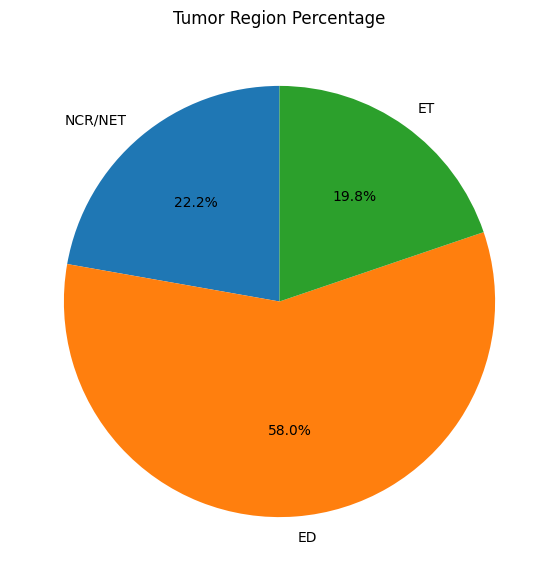

In [11]:
plt.figure(figsize=(7,7))

plt.pie(
    tumor_df["Voxel Count"],
    labels=["NCR/NET","ED","ET"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Tumor Region Percentage")

plt.show()

In [12]:
label_names = {
    1: "NCR/NET",
    2: "ED",
    4: "ET"
}

tumor_df["Region"] = tumor_df["Label"].map(label_names)

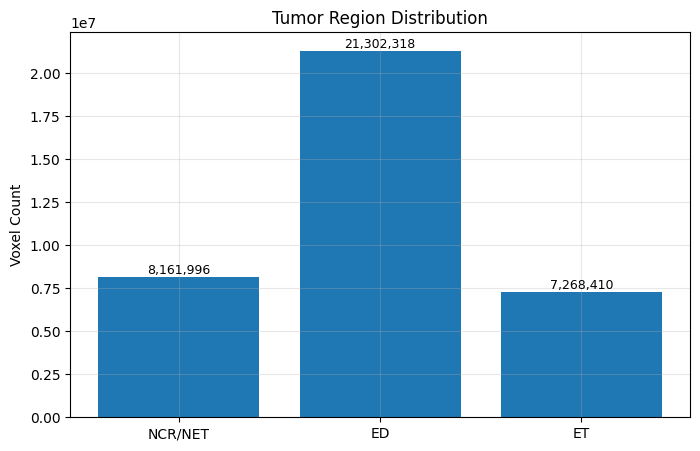

In [13]:
fig, ax = plt.subplots(figsize=(8,5))

bars = ax.bar(
    tumor_df["Region"],
    tumor_df["Voxel Count"]
)

for bar in bars:

    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title("Tumor Region Distribution")

plt.ylabel("Voxel Count")

plt.grid(alpha=.3)

plt.show()

### Observation

Voxel-level analysis reveals a severe class imbalance within the BraTS2020 dataset.

Approximately **98.89%** of all voxels belong to the background class, while the three tumor subregions together occupy only about **1.11%** of the dataset.

Among the tumor regions:

- **Edema (Label 2)** is the largest tumor component.
- **Necrotic / Non-Enhancing Tumor Core (Label 1)** is smaller.
- **Enhancing Tumor (Label 4)** is the smallest region.

These findings have several important implications for model development:

- Accuracy is not an appropriate evaluation metric.
- Dice-based loss functions are more suitable than standard Cross-Entropy alone.
- Patch sampling should prioritize foreground regions to reduce the overwhelming dominance of background voxels.

## Engineering Decision

Based on the voxel distribution analysis:

- Dice-based optimization will be preferred over accuracy-based optimization.
- Foreground-aware patch sampling will be used during training.
- Class imbalance will be addressed through suitable loss functions rather than simple random sampling.

# Tumor Volume Distribution

The total tumor burden varies considerably between patients.

This section measures the tumor volume for every patient by counting the number of voxels belonging to tumor tissue.

Understanding tumor size variability helps determine suitable patch sizes, sampling strategies, and augmentation policies during model training.

In [14]:
tumor_volume = []

In [15]:
for patient in tqdm(patients):

    seg_path = get_modality_path(patient, "seg")

    mask = nib.load(str(seg_path)).get_fdata()

    tumor_voxels = np.sum(mask > 0)

    tumor_volume.append({

        "Patient": patient.name,

        "Tumor Voxels": tumor_voxels
    })

  0%|          | 0/369 [00:00<?, ?it/s]

In [16]:
tumor_volume_df = pd.DataFrame(tumor_volume)

tumor_volume_df.head()

,Patient,Tumor Voxels
0,BraTS20_Training_001,211979
1,BraTS20_Training_002,67008
2,BraTS20_Training_003,29807
3,BraTS20_Training_004,103496
4,BraTS20_Training_005,21963


In [17]:
tumor_volume_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Tumor Voxels,369.0,99546.677507,59429.143217,7285.0,50735.0,90740.0,145124.0,361783.0


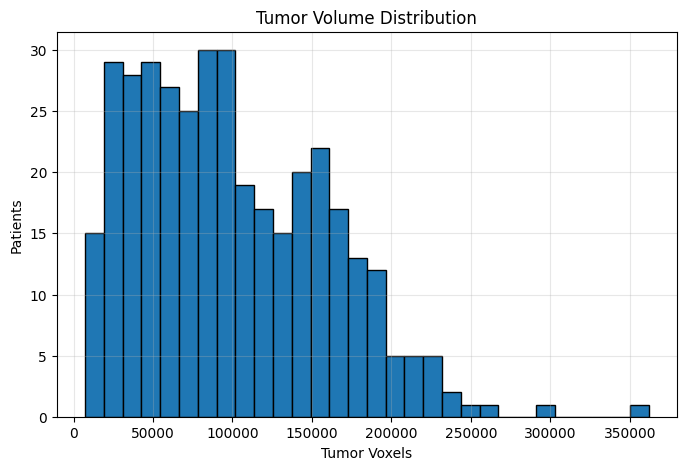

In [18]:
plt.figure(figsize=(8,5))

plt.hist(

    tumor_volume_df["Tumor Voxels"],

    bins=30,

    edgecolor="black"

)

plt.title("Tumor Volume Distribution")

plt.xlabel("Tumor Voxels")

plt.ylabel("Patients")

plt.grid(alpha=.3)

plt.show()

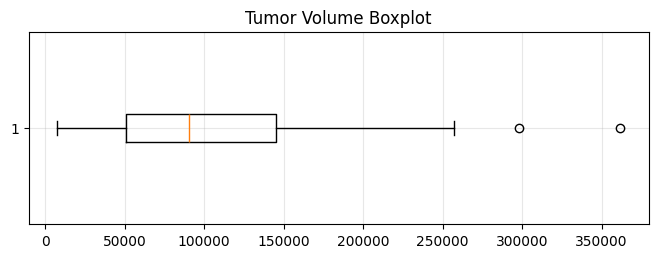

In [19]:
plt.figure(figsize=(8,2.5))

plt.boxplot(

    tumor_volume_df["Tumor Voxels"],

    vert=False

)

plt.title("Tumor Volume Boxplot")

plt.grid(alpha=.3)

plt.show()

In [20]:
tumor_volume_df.sort_values(

    by="Tumor Voxels",

    ascending=False

).head(10)

,Patient,Tumor Voxels
327,BraTS20_Training_328,361783
292,BraTS20_Training_293,298075
148,BraTS20_Training_149,256875
260,BraTS20_Training_261,248267
322,BraTS20_Training_323,232098
315,BraTS20_Training_316,231951
272,BraTS20_Training_273,230882
240,BraTS20_Training_241,227126
368,BraTS20_Training_369,224832
165,BraTS20_Training_166,222999


### Observation

Tumor volume varies substantially across patients.

The analysis shows that most tumors occupy between **50,000 and 150,000 voxels**, while a small number of patients exhibit significantly larger tumor burdens.

The histogram and boxplot indicate a positively skewed distribution with several large-tumor outliers.

This variability reflects the natural heterogeneity of gliomas and highlights the importance of designing a segmentation pipeline that performs well across both small and large tumors.

## Engineering Decision

Based on the tumor volume analysis:

- The preprocessing pipeline should avoid assuming a fixed tumor size.
- Patch-based training will be preferred over processing entire MRI volumes.
- Foreground-aware sampling will be adopted to ensure that small tumors are frequently observed during training.
- Data augmentation should preserve tumor morphology while improving robustness to size variability.

# Tumor Slice Distribution

Tumor voxels alone do not fully describe tumor size.

Another important characteristic is the number of MRI slices containing tumor tissue.

Patients with the same tumor volume may have completely different spatial distributions.

This analysis measures the number of slices containing tumor voxels for every patient.

In [21]:
slice_statistics = []

In [22]:
for patient in tqdm(patients):

    seg_path = get_modality_path(patient, "seg")

    mask = nib.load(str(seg_path)).get_fdata()

    tumor_slices = np.sum(

        np.any(mask > 0, axis=(0,1))

    )

    slice_statistics.append({

        "Patient": patient.name,

        "Tumor Slices": tumor_slices

    })

  0%|          | 0/369 [00:00<?, ?it/s]

In [23]:
slice_df = pd.DataFrame(slice_statistics)

slice_df.head()

,Patient,Tumor Slices
0,BraTS20_Training_001,83
1,BraTS20_Training_002,55
2,BraTS20_Training_003,52
3,BraTS20_Training_004,68
4,BraTS20_Training_005,51


In [24]:
slice_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Tumor Slices,369.0,66.184282,15.046619,23.0,56.0,68.0,78.0,102.0


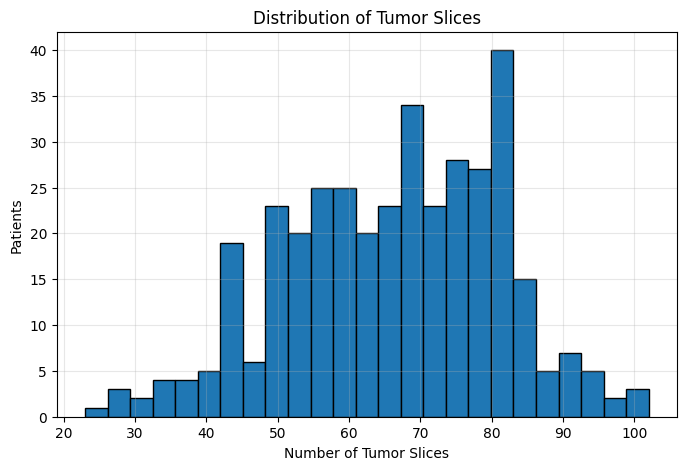

In [25]:
plt.figure(figsize=(8,5))

plt.hist(

    slice_df["Tumor Slices"],

    bins=25,

    edgecolor="black"

)

plt.title("Distribution of Tumor Slices")

plt.xlabel("Number of Tumor Slices")

plt.ylabel("Patients")

plt.grid(alpha=.3)

plt.show()

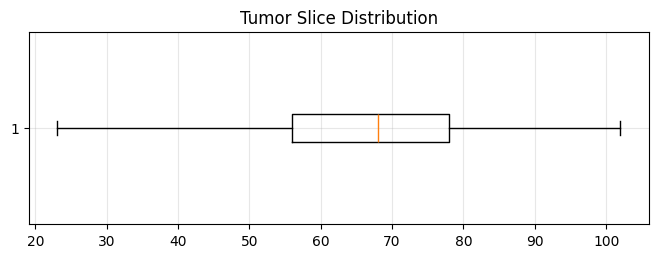

In [26]:
plt.figure(figsize=(8,2.5))

plt.boxplot(

    slice_df["Tumor Slices"],

    vert=False

)

plt.title("Tumor Slice Distribution")

plt.grid(alpha=.3)

plt.show()

In [27]:
slice_df.sort_values(

    by="Tumor Slices",

    ascending=False

).head(10)

,Patient,Tumor Slices
368,BraTS20_Training_369,102
327,BraTS20_Training_328,102
69,BraTS20_Training_070,102
63,BraTS20_Training_064,98
147,BraTS20_Training_148,97
164,BraTS20_Training_165,95
68,BraTS20_Training_069,95
154,BraTS20_Training_155,94
74,BraTS20_Training_075,94
235,BraTS20_Training_236,94


In [28]:
slice_df.sort_values(

    by="Tumor Slices"

).head(10)

,Patient,Tumor Slices
98,BraTS20_Training_099,23
267,BraTS20_Training_268,27
78,BraTS20_Training_079,29
340,BraTS20_Training_341,29
107,BraTS20_Training_108,30
176,BraTS20_Training_177,32
263,BraTS20_Training_264,33
81,BraTS20_Training_082,34
121,BraTS20_Training_122,34
324,BraTS20_Training_325,35


### Observation

The number of MRI slices containing tumor tissue varies across patients.

Key findings:

- Mean tumor slices: **66.2**
- Median tumor slices: **68**
- Minimum: **23**
- Maximum: **102**

Considering that every MRI volume contains **155 slices**, tumors occupy approximately **43%** of the available slices on average.

This indicates that a considerable proportion of slices do not contain tumor tissue, which should be considered during model training and sampling.

## Engineering Decision

Based on the tumor slice distribution:

- Training should avoid uniformly sampling all slices.
- Slice filtering or foreground-aware patch sampling should be preferred.
- A full 3D segmentation approach remains appropriate because tumors extend across many consecutive slices.
- Data augmentation should preserve spatial continuity across neighboring slices.

# Tumor Position Analysis

Tumor size alone is not sufficient to understand its spatial distribution.

This section analyzes the anatomical location of tumors by identifying:

- The first slice containing tumor tissue.
- The last slice containing tumor tissue.
- The center slice of the tumor.

Understanding tumor position helps design efficient cropping and patch sampling strategies.

In [29]:
tumor_position = []

In [30]:
for patient in tqdm(patients):

    seg_path = get_modality_path(patient, "seg")

    mask = nib.load(str(seg_path)).get_fdata()

    tumor_slices = np.where(
        np.any(mask > 0, axis=(0, 1))
    )[0]

    tumor_position.append({

        "Patient": patient.name,

        "First Slice": tumor_slices.min(),

        "Last Slice": tumor_slices.max(),

        "Center Slice": int(tumor_slices.mean())
    })

  0%|          | 0/369 [00:00<?, ?it/s]

In [31]:
position_df = pd.DataFrame(tumor_position)

position_df.head()

,Patient,First Slice,Last Slice,Center Slice
0,BraTS20_Training_001,30,112,71
1,BraTS20_Training_002,27,81,54
2,BraTS20_Training_003,58,109,83
3,BraTS20_Training_004,54,121,87
4,BraTS20_Training_005,79,129,104


In [32]:
position_df.describe().T

,count,mean,std,min,25%,50%,75%,max
First Slice,369.0,46.937669,16.682258,15.0,33.0,45.0,58.0,102.0
Last Slice,369.0,112.723577,19.286865,49.0,99.0,114.0,129.0,143.0
Center Slice,369.0,79.582656,16.537649,32.0,66.0,80.0,93.0,116.0


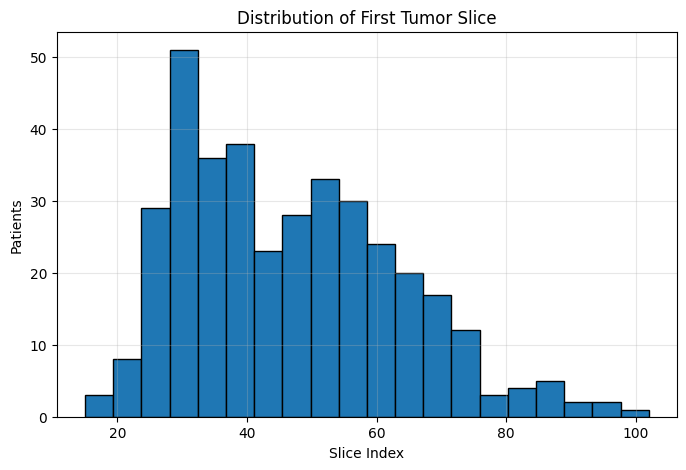

In [33]:
plt.figure(figsize=(8,5))

plt.hist(
    position_df["First Slice"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of First Tumor Slice")

plt.xlabel("Slice Index")

plt.ylabel("Patients")

plt.grid(alpha=0.3)

plt.show()

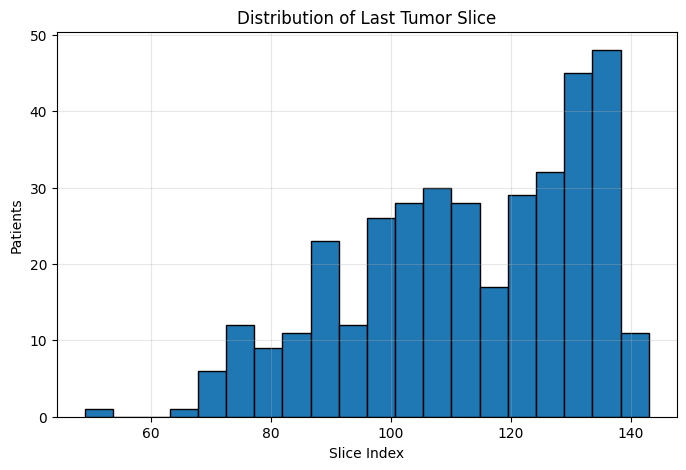

In [34]:
plt.figure(figsize=(8,5))

plt.hist(
    position_df["Last Slice"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Last Tumor Slice")

plt.xlabel("Slice Index")

plt.ylabel("Patients")

plt.grid(alpha=0.3)

plt.show()

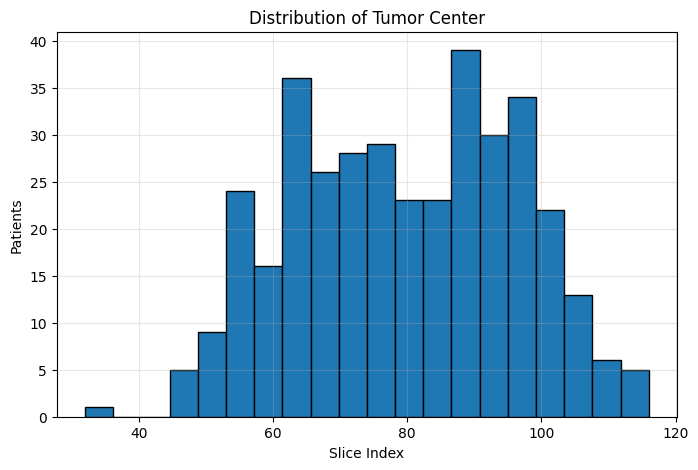

In [35]:
plt.figure(figsize=(8,5))

plt.hist(
    position_df["Center Slice"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Tumor Center")

plt.xlabel("Slice Index")

plt.ylabel("Patients")

plt.grid(alpha=0.3)

plt.show()

In [36]:
position_df.sort_values(
    by="First Slice"
).head(10)

,Patient,First Slice,Last Slice,Center Slice
19,BraTS20_Training_020,15,94,54
324,BraTS20_Training_325,15,49,32
216,BraTS20_Training_217,19,70,48
287,BraTS20_Training_288,22,77,49
293,BraTS20_Training_294,23,81,52
241,BraTS20_Training_242,23,72,47
244,BraTS20_Training_245,23,99,61
63,BraTS20_Training_064,23,120,71
194,BraTS20_Training_195,23,73,48
164,BraTS20_Training_165,23,117,70


In [37]:
position_df.sort_values(
    by="Last Slice",
    ascending=False
).head(10)

,Patient,First Slice,Last Slice,Center Slice
368,BraTS20_Training_369,42,143,92
61,BraTS20_Training_062,61,142,101
320,BraTS20_Training_321,86,142,114
134,BraTS20_Training_135,59,142,100
156,BraTS20_Training_157,70,141,105
354,BraTS20_Training_355,74,141,107
33,BraTS20_Training_034,74,140,107
131,BraTS20_Training_132,58,139,98
175,BraTS20_Training_176,71,139,105
139,BraTS20_Training_140,74,139,106


### Observation

The spatial analysis reveals that brain tumors are consistently located near the center of the MRI volumes.

Key findings include:

- The average first tumor slice is **46.9**.
- The average last tumor slice is **112.7**.
- The average tumor center is **79.6**, which is close to the middle of the 155-slice MRI volume.

These findings indicate that tumors rarely appear near the extreme superior or inferior slices of the volume.

The consistency of tumor location reflects the standardized preprocessing and registration applied in the BraTS2020 dataset.

## Engineering Decision

The tumor position analysis suggests that:

- ROI-based cropping can focus on the central portion of the MRI volume.
- Extremely early and late slices contain limited useful information and should not dominate the sampling strategy.
- Patch extraction should prioritize regions around the tumor center rather than uniformly sampling the entire volume.

# Tumor Bounding Box Analysis

Rather than analyzing only tumor volume, we estimate the spatial extent of each tumor.

For every patient, the minimum bounding box surrounding the tumor is computed.

The bounding box dimensions provide valuable information for:

- ROI cropping
- Patch extraction
- GPU memory optimization
- Preprocessing design

In [38]:
bbox_statistics = []

In [39]:
for patient in tqdm(patients):

    seg_path = get_modality_path(patient, "seg")

    mask = nib.load(str(seg_path)).get_fdata()

    coords = np.argwhere(mask > 0)

    xmin, ymin, zmin = coords.min(axis=0)
    xmax, ymax, zmax = coords.max(axis=0)

    bbox_statistics.append({

        "Patient": patient.name,

        "X Min": xmin,
        "X Max": xmax,

        "Y Min": ymin,
        "Y Max": ymax,

        "Z Min": zmin,
        "Z Max": zmax,

        "Width": xmax - xmin + 1,
        "Height": ymax - ymin + 1,
        "Depth": zmax - zmin + 1
    })

  0%|          | 0/369 [00:00<?, ?it/s]

In [40]:
bbox_df = pd.DataFrame(bbox_statistics)

bbox_df.head()

,Patient,X Min,X Max,Y Min,Y Max,Z Min,Z Max,Width,Height,Depth
0,BraTS20_Training_001,51,143,77,186,30,112,93,110,83
1,BraTS20_Training_002,55,115,80,169,27,81,61,90,55
2,BraTS20_Training_003,125,180,120,183,58,109,56,64,52
3,BraTS20_Training_004,125,180,123,201,54,121,56,79,68
4,BraTS20_Training_005,117,175,145,193,79,129,59,49,51


In [41]:
bbox_df.describe().T

,count,mean,std,min,25%,50%,75%,max
X Min,369.0,89.636856,30.922384,45.0,60.0,85.0,119.0,155.0
X Max,369.0,151.672087,29.027504,83.0,123.0,159.0,178.0,239.0
Y Min,369.0,89.452575,27.415851,29.0,73.0,87.0,108.0,158.0
Y Max,369.0,172.696477,24.520732,93.0,153.0,174.0,193.0,215.0
Z Min,369.0,46.937669,16.682258,15.0,33.0,45.0,58.0,102.0
Z Max,369.0,112.723577,19.286865,49.0,99.0,114.0,129.0,143.0
Width,369.0,63.035230,17.293859,25.0,52.0,61.0,73.0,126.0
Height,369.0,84.243902,21.788013,27.0,70.0,84.0,98.0,162.0
Depth,369.0,66.785908,15.068871,23.0,56.0,68.0,78.0,104.0


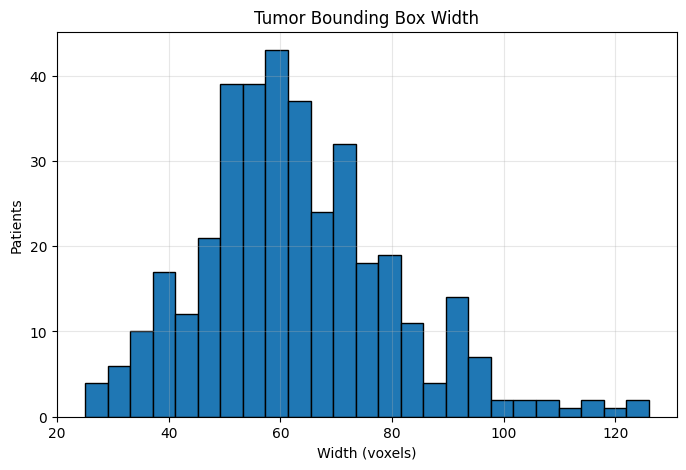

In [42]:
plt.figure(figsize=(8,5))

plt.hist(
    bbox_df["Width"],
    bins=25,
    edgecolor="black"
)

plt.title("Tumor Bounding Box Width")

plt.xlabel("Width (voxels)")

plt.ylabel("Patients")

plt.grid(alpha=.3)

plt.show()

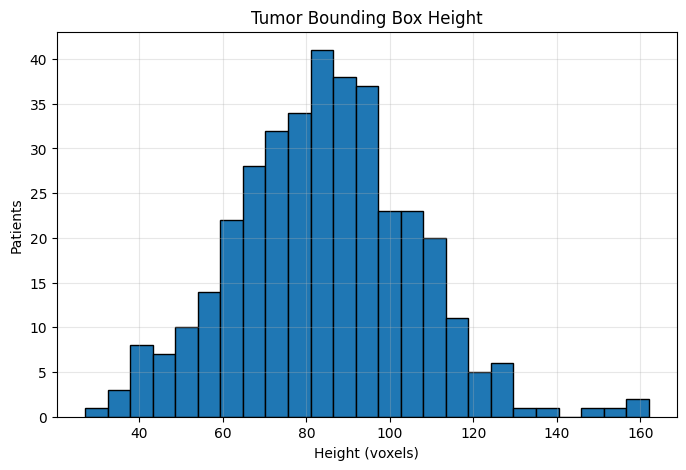

In [43]:
plt.figure(figsize=(8,5))

plt.hist(
    bbox_df["Height"],
    bins=25,
    edgecolor="black"
)

plt.title("Tumor Bounding Box Height")

plt.xlabel("Height (voxels)")

plt.ylabel("Patients")

plt.grid(alpha=.3)

plt.show()

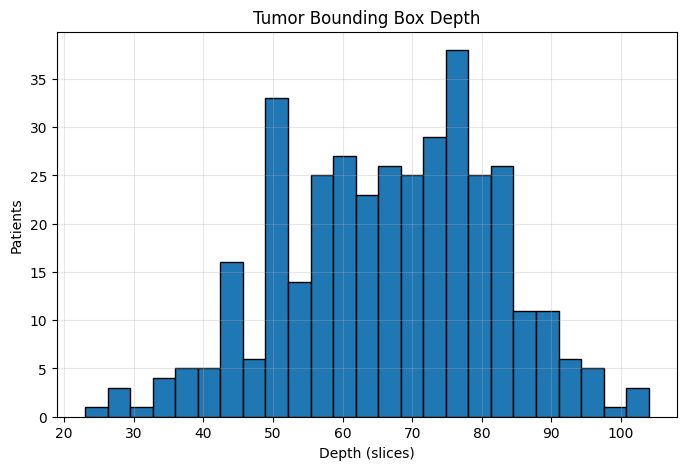

In [44]:
plt.figure(figsize=(8,5))

plt.hist(
    bbox_df["Depth"],
    bins=25,
    edgecolor="black"
)

plt.title("Tumor Bounding Box Depth")

plt.xlabel("Depth (slices)")

plt.ylabel("Patients")

plt.grid(alpha=.3)

plt.show()

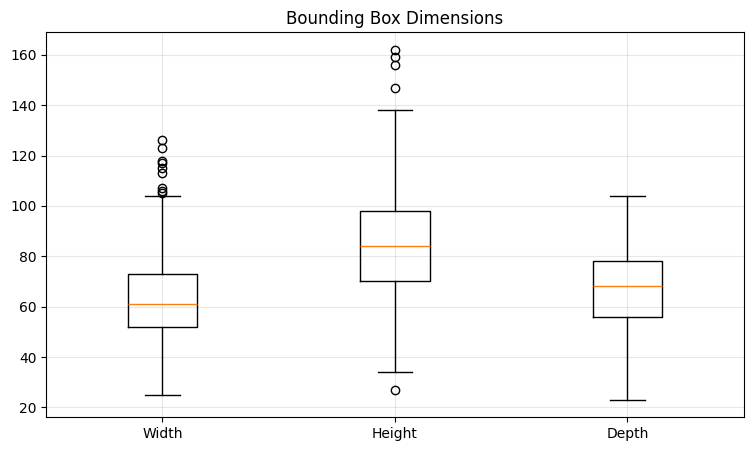

In [45]:
plt.figure(figsize=(9,5))

plt.boxplot(
    [
        bbox_df["Width"],
        bbox_df["Height"],
        bbox_df["Depth"]
    ],
    tick_labels=["Width","Height","Depth"]
)

plt.title("Bounding Box Dimensions")

plt.grid(alpha=.3)

plt.show()

In [46]:
merged_df = tumor_volume_df.merge(
    bbox_df,
    on="Patient"
)

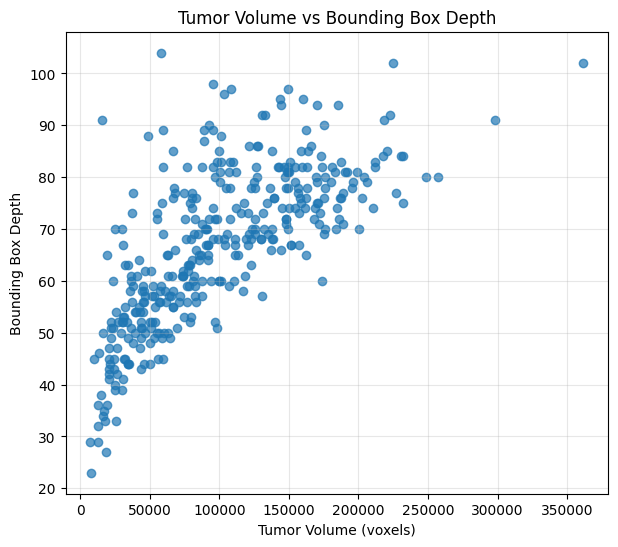

In [47]:
plt.figure(figsize=(7,6))

plt.scatter(

    merged_df["Tumor Voxels"],

    merged_df["Depth"],

    alpha=0.7

)

plt.title("Tumor Volume vs Bounding Box Depth")

plt.xlabel("Tumor Volume (voxels)")

plt.ylabel("Bounding Box Depth")

plt.grid(alpha=.3)

plt.show()

In [48]:
merged_df[

    [
        "Tumor Voxels",
        "Width",
        "Height",
        "Depth"

    ]

].corr()

,Tumor Voxels,Width,Height,Depth
Tumor Voxels,1.000000,0.673060,0.711317,0.714767
Width,0.673060,1.000000,0.659055,0.577931
Height,0.711317,0.659055,1.000000,0.651564
Depth,0.714767,0.577931,0.651564,1.000000


In [49]:
bbox_df.sort_values(

    by="Depth",

    ascending=False

).head(10)

,Patient,X Min,X Max,Y Min,Y Max,Z Min,Z Max,Width,Height,Depth
69,BraTS20_Training_070,55,117,75,156,33,136,63,82,104
368,BraTS20_Training_369,66,183,48,206,42,143,118,159,102
327,BraTS20_Training_328,58,161,42,154,30,131,104,113,102
63,BraTS20_Training_064,64,121,81,174,23,120,58,94,98
105,BraTS20_Training_106,86,171,51,212,38,134,86,162,97
147,BraTS20_Training_148,119,187,50,205,41,137,69,156,97
113,BraTS20_Training_114,87,179,63,179,36,131,93,117,96
164,BraTS20_Training_165,85,180,87,200,23,117,96,114,95
68,BraTS20_Training_069,66,172,58,204,39,133,107,147,95
154,BraTS20_Training_155,120,174,106,206,37,130,55,101,94


In [50]:
bbox_df.sort_values(

    by="Depth"

).head(10)

,Patient,X Min,X Max,Y Min,Y Max,Z Min,Z Max,Width,Height,Depth
98,BraTS20_Training_099,130,165,113,177,44,66,36,65,23
267,BraTS20_Training_268,64,97,112,164,42,68,34,53,27
78,BraTS20_Training_079,76,100,112,138,102,130,25,27,29
340,BraTS20_Training_341,155,182,108,155,45,73,28,48,29
176,BraTS20_Training_177,79,111,138,176,40,71,33,39,32
263,BraTS20_Training_264,65,105,53,93,61,93,41,41,33
107,BraTS20_Training_108,89,173,92,181,36,68,85,90,33
121,BraTS20_Training_122,151,185,119,153,68,101,35,35,34
324,BraTS20_Training_325,98,132,136,173,15,49,35,38,35
141,BraTS20_Training_142,78,106,125,158,87,122,29,34,36


### Observation

Bounding box analysis reveals substantial variability in tumor spatial dimensions.

The average tumor bounding box measures approximately:

- Width: 63 voxels
- Height: 84 voxels
- Depth: 67 slices

The distributions indicate moderate variability with a limited number of large tumors.

Correlation analysis demonstrates a strong positive relationship between tumor volume and bounding box dimensions.

These findings confirm that tumor extent varies considerably across patients while remaining spatially localized.

## Engineering Decision

Bounding box statistics will directly guide preprocessing.

Based on the observed tumor dimensions:

- ROI-based cropping will be adopted instead of processing the entire MRI volume.
- Patch-based training will be preferred to reduce GPU memory usage.
- Patch sizes should comfortably exceed the average tumor dimensions while remaining computationally efficient.
- Dynamic foreground-aware cropping is preferred over fixed global cropping.

# Tumor Slice Ratio Analysis

Although every MRI volume contains 155 slices, only a subset contains tumor tissue.

This analysis measures the proportion of slices containing tumor tissue versus background-only slices.

The results will guide sampling strategies during model training.

In [51]:
ratio_statistics = []

TOTAL_SLICES = 155

In [52]:
for patient in tqdm(patients):

    seg_path = get_modality_path(patient, "seg")

    mask = nib.load(str(seg_path)).get_fdata()

    tumor_slices = np.sum(
        np.any(mask > 0, axis=(0,1))
    )

    empty_slices = TOTAL_SLICES - tumor_slices

    ratio_statistics.append({

        "Patient": patient.name,

        "Tumor Slices": tumor_slices,

        "Empty Slices": empty_slices,

        "Tumor Ratio": tumor_slices / TOTAL_SLICES,

        "Empty Ratio": empty_slices / TOTAL_SLICES
    })

  0%|          | 0/369 [00:00<?, ?it/s]

In [53]:
ratio_df = pd.DataFrame(ratio_statistics)

ratio_df.head()

,Patient,Tumor Slices,Empty Slices,Tumor Ratio,Empty Ratio
0,BraTS20_Training_001,83,72,0.535484,0.464516
1,BraTS20_Training_002,55,100,0.354839,0.645161
2,BraTS20_Training_003,52,103,0.335484,0.664516
3,BraTS20_Training_004,68,87,0.438710,0.561290
4,BraTS20_Training_005,51,104,0.329032,0.670968


In [54]:
ratio_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Tumor Slices,369.0,66.184282,15.046619,23.000000,56.000000,68.00000,78.000000,102.000000
Empty Slices,369.0,88.815718,15.046619,53.000000,77.000000,87.00000,99.000000,132.000000
Tumor Ratio,369.0,0.426995,0.097075,0.148387,0.361290,0.43871,0.503226,0.658065
Empty Ratio,369.0,0.573005,0.097075,0.341935,0.496774,0.56129,0.638710,0.851613


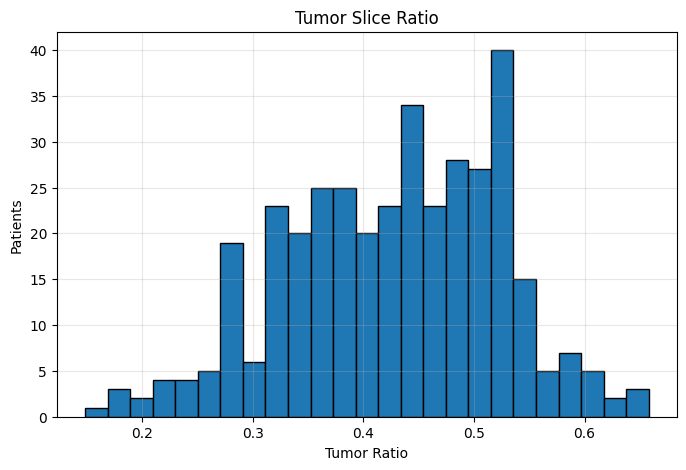

In [55]:
plt.figure(figsize=(8,5))

plt.hist(
    ratio_df["Tumor Ratio"],
    bins=25,
    edgecolor="black"
)

plt.title("Tumor Slice Ratio")

plt.xlabel("Tumor Ratio")

plt.ylabel("Patients")

plt.grid(alpha=0.3)

plt.show()

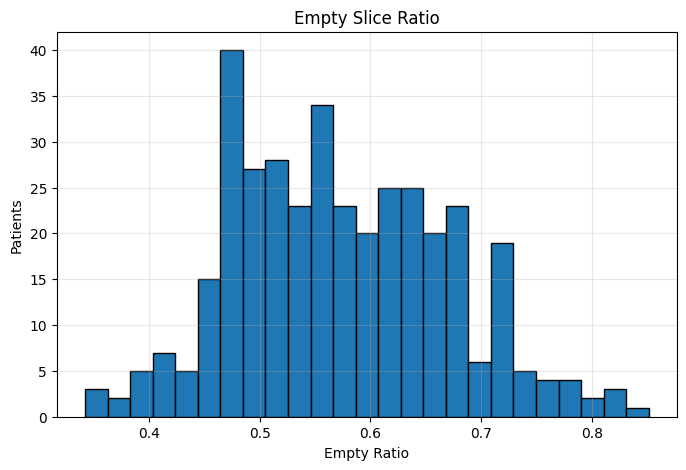

In [56]:
plt.figure(figsize=(8,5))

plt.hist(
    ratio_df["Empty Ratio"],
    bins=25,
    edgecolor="black"
)

plt.title("Empty Slice Ratio")

plt.xlabel("Empty Ratio")

plt.ylabel("Patients")

plt.grid(alpha=0.3)

plt.show()

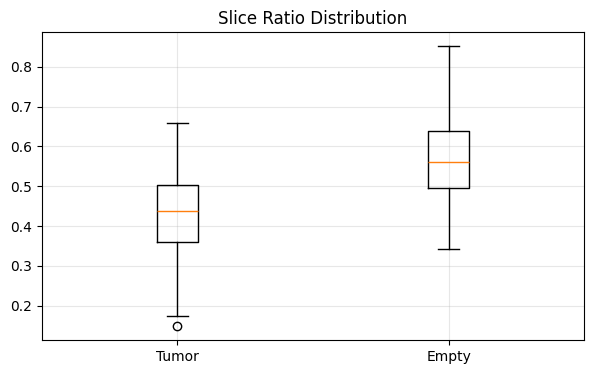

In [57]:
plt.figure(figsize=(7,4))

plt.boxplot(
    [
        ratio_df["Tumor Ratio"],
        ratio_df["Empty Ratio"]
    ],
    tick_labels=["Tumor","Empty"]
)

plt.title("Slice Ratio Distribution")

plt.grid(alpha=.3)

plt.show()

### Observation

The slice ratio analysis demonstrates that tumor tissue occupies approximately **43%** of MRI slices on average, while the remaining **57%** contain no tumor tissue.

Although tumors extend across many consecutive slices, a considerable portion of each MRI volume still contains healthy brain tissue only.

This finding confirms that blindly sampling slices from the entire MRI volume would introduce unnecessary background information during training.

## Engineering Decision

Based on the slice ratio analysis:

- Uniform slice sampling should be avoided.
- Foreground-aware sampling will be adopted.
- ROI cropping will be preferred over processing the full MRI volume.
- Patch extraction should focus on tumor-containing regions while still preserving sufficient contextual information.

# MRI Modalities Comparison

BraTS2020 provides four complementary MRI modalities.

Each modality highlights different anatomical or pathological characteristics.

Understanding their clinical role helps justify the use of multimodal segmentation networks.

In [58]:
modality_info = pd.DataFrame({

    "Modality":[
        "T1",
        "T1ce",
        "T2",
        "FLAIR"
    ],

    "Primary Information":[

        "Brain anatomy",

        "Contrast-enhancing tumor",

        "Edema and fluid",

        "Edema with CSF suppression"

    ],

    "Clinical Importance":[

        "Structural reference",

        "Enhancing tumor detection",

        "Tumor extent",

        "Edema visualization"

    ]
})

modality_info

,Modality,Primary Information,Clinical Importance
0,T1,Brain anatomy,Structural reference
1,T1ce,Contrast-enhancing tumor,Enhancing tumor detection
2,T2,Edema and fluid,Tumor extent
3,FLAIR,Edema with CSF suppression,Edema visualization


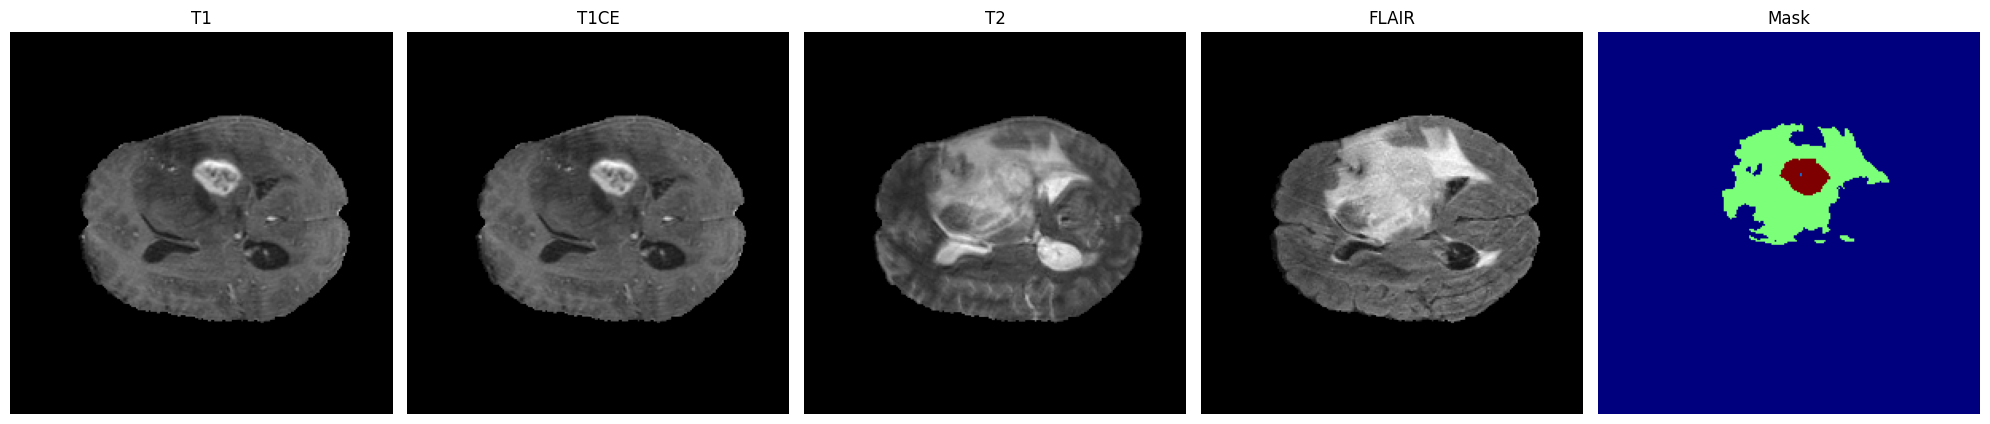

In [59]:
patient = patients[0]

modalities = ["t1", "t1ce", "t2", "flair"]

slice_idx = 77

fig, axes = plt.subplots(1, 5, figsize=(20,5))

for ax, modality in zip(axes[:4], modalities):

    volume = nib.load(
        str(get_modality_path(patient, modality))
    ).get_fdata()

    ax.imshow(volume[:, :, slice_idx], cmap="gray")
    ax.set_title(modality.upper())
    ax.axis("off")

mask = nib.load(
    str(get_modality_path(patient, "seg"))
).get_fdata()

axes[4].imshow(mask[:, :, slice_idx], cmap="jet")
axes[4].set_title("Mask")
axes[4].axis("off")

plt.tight_layout()

plt.show()

### Observation

The four MRI modalities provide complementary anatomical and pathological information.

- **T1** primarily depicts normal brain anatomy.
- **T1ce** highlights contrast-enhancing tumor tissue.
- **T2** emphasizes fluid accumulation and edema.
- **FLAIR** suppresses cerebrospinal fluid signals while preserving edema, making tumor extent easier to visualize.

The segmentation mask aligns well with abnormal regions observed across the modalities, confirming the complementary role of multimodal MRI in brain tumor segmentation.

## Engineering Decision

The analysis confirms that no single MRI modality contains sufficient information for accurate tumor segmentation.

Therefore:

- All four MRI modalities will be used as input channels.
- The preprocessing pipeline will normalize each modality independently.
- The segmentation network will receive a four-channel volumetric input.

# Final Clinical Insights

The medical analysis of BraTS2020 reveals several important characteristics:

- Severe voxel-level class imbalance.
- Considerable variability in tumor size across patients.
- Tumors are predominantly located near the center of MRI volumes.
- Tumor spatial extent varies but remains localized.
- MRI intensities differ substantially across modalities and patients.
- Most MRI slices do not contain tumor tissue.
- All scans share consistent spatial resolution and dimensions.

These findings form the basis for designing a robust segmentation pipeline.

In [60]:
engineering_decisions = pd.DataFrame({

    "Finding":[

        "Severe class imbalance",

        "Large tumor variability",

        "Tumor centered in volume",

        "Bounding boxes localized",

        "Intensity outliers",

        "Consistent voxel spacing",

        "High empty slice ratio"

    ],

    "Engineering Decision":[

        "Dice-based loss",

        "Patch-based training",

        "ROI-based cropping",

        "Foreground-aware patch sampling",

        "Percentile clipping + Z-score",

        "No resampling required",

        "Avoid uniform slice sampling"

    ]

})

engineering_decisions

,Finding,Engineering Decision
0,Severe class imbalance,Dice-based loss
1,Large tumor variability,Patch-based training
2,Tumor centered in volume,ROI-based cropping
3,Bounding boxes localized,Foreground-aware patch sampling
4,Intensity outliers,Percentile clipping + Z-score
5,Consistent voxel spacing,No resampling required
6,High empty slice ratio,Avoid uniform slice sampling


# Notebook Summary

In this notebook, a comprehensive medical analysis of the BraTS2020 dataset was conducted.

The analyses included:

- Tumor region distribution
- Tumor volume analysis
- Tumor slice distribution
- Tumor spatial position
- Tumor bounding box analysis
- Slice ratio analysis
- MRI modality comparison

The resulting observations provide direct guidance for preprocessing, data loading, model architecture, and training strategy.

The next notebook will implement the preprocessing pipeline based on these findings.